In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [16]:
# Make the corner plot for the MCMC results
system_name = '2M1134'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [17]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,52.53043,332.0260,1.115581,1.651493,0.895387,43.35013
1,53.36266,332.1851,1.114817,1.650839,0.895386,43.27163
2,54.67244,332.4162,1.113331,1.654125,0.895448,43.26689
3,60.39928,332.6746,1.111499,1.658861,0.895189,43.23134
4,56.44391,331.9964,1.103907,1.658125,0.895267,43.20044
...,...,...,...,...,...,...
1083,58.98770,331.0388,1.115709,1.656507,0.892116,43.29844
1084,62.12327,330.6400,1.101282,1.660944,0.891969,43.21950
1085,58.54877,331.0182,1.109563,1.651325,0.892182,43.20034
1086,62.72811,330.7683,1.111255,1.644793,0.892138,43.17819


In [20]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [ ]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

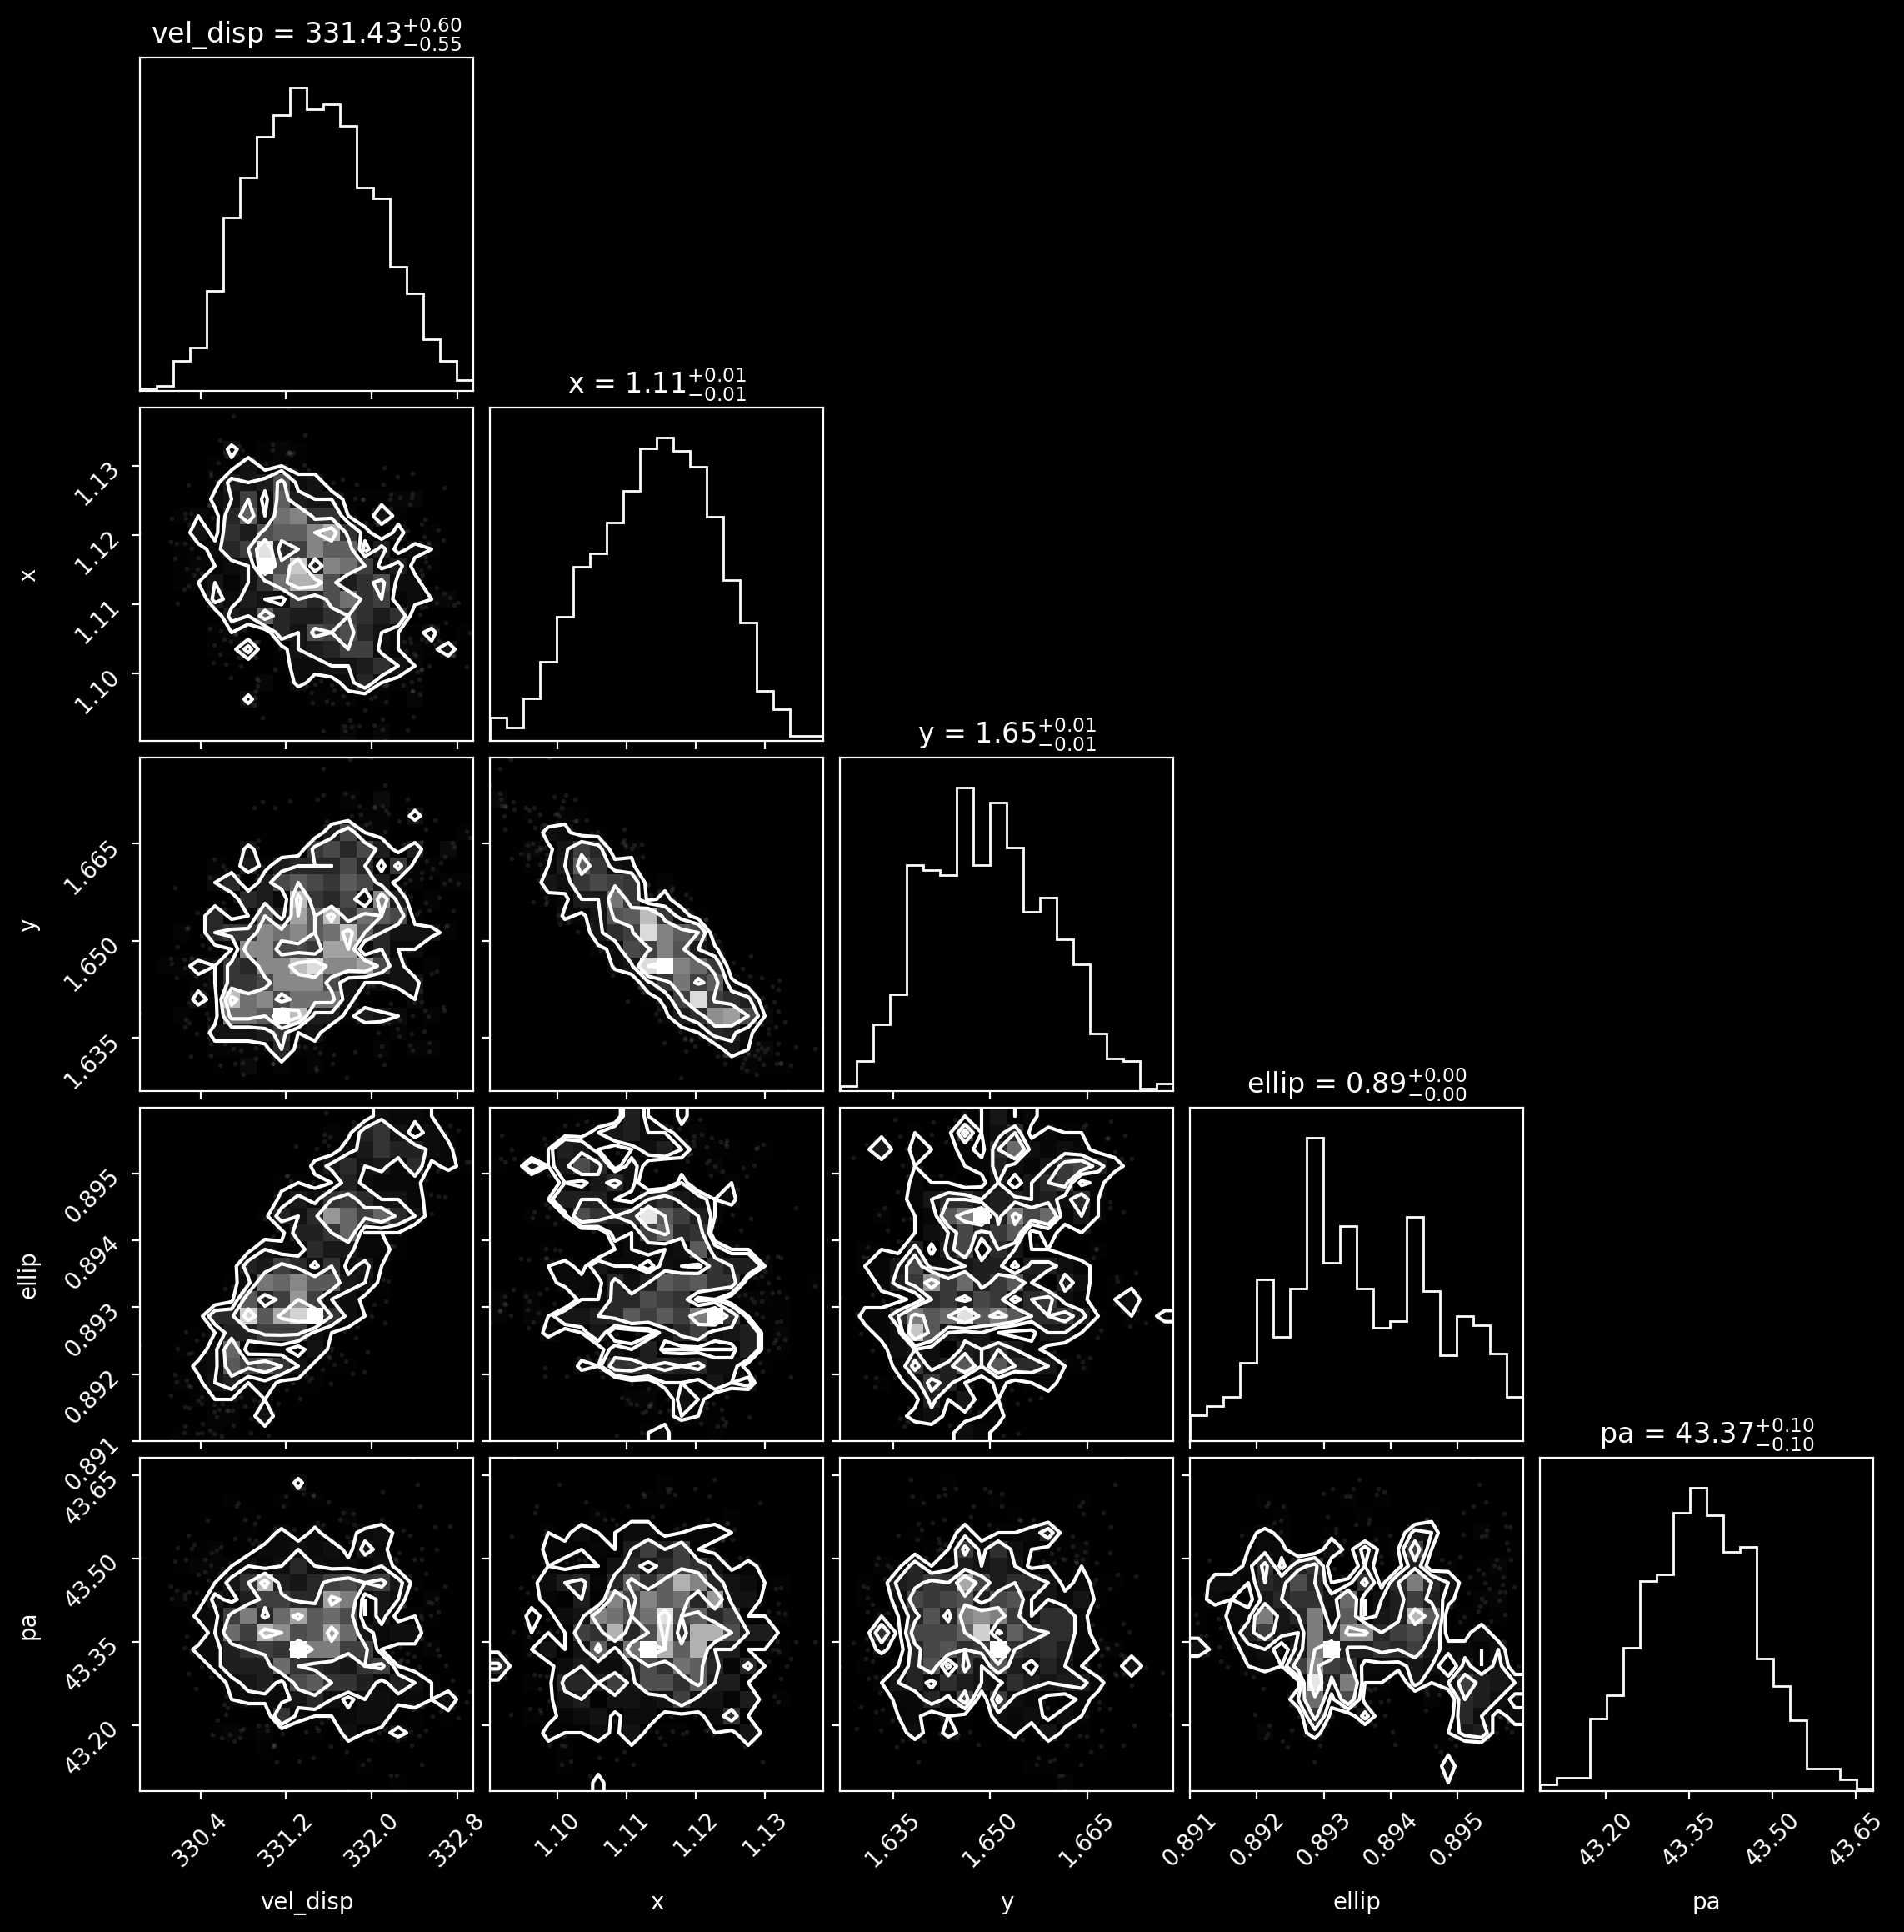

In [22]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')